# FinBot: Financial Stock Analysis Agent with MCP
### AWS Bedrock Strands + FastMCP HTTP Server

---

This tutorial builds a financial stock analysis agent using **FastMCP** over **HTTP transport**.
The MCP server runs as a standalone HTTP service; clients connect using `fastmcp.Client`.

| Component | Technology | Role |
|---|---|---|
| **MCP Server** | FastMCP + `streamable-http` | Exposes 6 stock tools over HTTP |
| **MCP Client** | `fastmcp.Client` | Connects to server, calls tools |
| **Agent** | AWS Bedrock Strands | LLM reasoning + tool-calling loop |
| **Data** | yfinance | Real-time Yahoo Finance data |

### What is MCP
The Model Context Protocol (MCP) is an open-source standard created by Anthropic that acts as a "USB-C for AI," providing a universal, standardized way for AI models to securely connect to external tools, data sources, and applications.
<a href="https://ibb.co/Xxxc2rF6"><img src="https://i.ibb.co/3mmgr9SV/Screenshot-2026-04-09-at-7-51-15-PM.png" alt="Screenshot-2026-04-09-at-7-51-15-PM" border="0"></a>

MCP Interaction Lifecycle

*   Initialization: The host application reads configurations and establishes a connection, exchanging protocol versions and capabilities with the MCP server.
*   Tool Discovery: The client sends a tools/list request, and the server replies with a JSON-RPC manifest listing its available tools, including their names, descriptions, and input/output schemas.
*   Execution (Tool Call): The LLM, detecting a need based on a prompt, generates a structured JSON request (tools/call) with parameters; the client sends this to the server, which executes the actual API call.
*   Termination: Shut down the connection

<a href="https://ibb.co/B5S7716P"><img src="https://i.ibb.co/FLjffPYW/Screenshot-2026-04-09-at-7-51-34-PM.png" alt="Screenshot-2026-04-09-at-7-51-34-PM" border="0"></a>

### FinBot: Architecture

```
Your Question
      ↓
Strands Agent  (AWS Bedrock Claude 4.0)
      ↓  HTTP POST + SSE  (streamable-http)
FastMCP Server  http://localhost:8765/mcp
      ↓  @mcp.tool decorated functions
yfinance  →  Yahoo Finance API
```

### Tutorial Outline
1. **Setup** — Install packages
2. **Build the FastMCP HTTP Server** — Define tools with `@mcp.tool`, run with `streamable-http`
3. **Start the Server** — Launch in a background subprocess
4. **Connect with `fastmcp.Client`** — List tools and inspect schemas
5. **Call Tools via HTTP** — Fetch live stock data
6. **Build the Strands Agent** — Wire FastMCP HTTP into Bedrock *(requires AWS credentials)*
7. **Run the Agent** — Ask natural language questions *(requires AWS credentials)*

## Part 1 — Setup

Install all required packages:
- **`fastmcp`** — MCP server framework + HTTP client
- **`nest_asyncio`** — Allows `asyncio` inside Jupyter/Colab event loops
- **`strands-agents`** — Agent framework for AWS Bedrock
- **`yfinance`** — Real-time stock data

In [2]:
!pip install -q fastmcp nest_asyncio strands-agents strands-agents-tools mcp yfinance matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 707.3/707.3 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.6/315.6 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Apply nest_asyncio so asyncio.run() / await work inside Jupyter & Colab
import nest_asyncio
nest_asyncio.apply()

import asyncio, json, os, subprocess, sys, time

print("Imports OK")

Imports OK


## Part 2 — Build the FastMCP HTTP Server

The server is a plain Python file with `@mcp.tool` decorated functions.

Key API:
```python
mcp = FastMCP(name="my-server")

@mcp.tool
def my_tool(param: str) -> str:
    """Tool description (shown to the LLM)."""
    return json.dumps({...})

```

In [5]:
SERVER_PATH = os.path.join(os.getcwd(), "stock_mcp_server.py")
MCP_HOST    = "127.0.0.1"
MCP_PORT    = 8765
MCP_URL     = f"http://{MCP_HOST}:{MCP_PORT}/mcp"

## Part 3 — Start the HTTP Server

Launch the FastMCP server as a **background subprocess**.
It listens on `http://127.0.0.1:8765/mcp` using the MCP `streamable-http` protocol.

In [6]:
import urllib.request, urllib.error

# Launch the FastMCP server as a background subprocess
server_proc = subprocess.Popen(
    [sys.executable, SERVER_PATH, "--host", MCP_HOST, "--port", str(MCP_PORT)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

# Poll until the server responds (HTTP 406 = server up, needs MCP headers)
ready = False
for _ in range(20):
    time.sleep(0.5)
    try:
        urllib.request.urlopen(MCP_URL, timeout=1)
        ready = True; break
    except urllib.error.HTTPError as e:
        if e.code == 406:
            ready = True; break
    except Exception:
        pass

print(f"FastMCP HTTP server running at {MCP_URL}")
print(f"Server PID      : {server_proc.pid}")

FastMCP HTTP server running at http://127.0.0.1:8765/mcp
Server PID      : 22118


In [7]:
!lsof -i :8765

COMMAND   PID USER   FD   TYPE DEVICE SIZE/OFF NODE NAME
python3 21965 root    6u  IPv4 604982      0t0  TCP localhost:8765 (LISTEN)


## Part 4 — Connect with `fastmcp.Client`

`fastmcp.Client` is the built-in HTTP client for FastMCP servers.
Passing a URL string automatically selects `StreamableHttpTransport`.

```python
from fastmcp import Client

async with Client("http://127.0.0.1:8765/mcp") as client:
    tools  = await client.list_tools()         # list registered tools
    result = await client.call_tool(           # call a tool
        "get_stock_price", {"symbol": "AAPL"}
    )
    data = json.loads(result.content[0].text)  # parse JSON response
```

In [8]:
from fastmcp import Client as FastMCPClient

async def list_tools():
    async with FastMCPClient(MCP_URL) as client:
        return await client.list_tools()

tools = asyncio.run(list_tools())
print(f"Connected via fastmcp.Client  →  {len(tools)} tools registered\n")
for t in tools:
    params   = list(t.inputSchema.get("properties", {}).keys())
    required = t.inputSchema.get("required", [])
    param_str = ", ".join(f"{p}*" if p in required else p for p in params)
    print(f"  @mcp.tool  {t.name}({param_str})")
    print(f"             {t.description.splitlines()[0]}")
    print()

Connected via fastmcp.Client  →  6 tools registered

  @mcp.tool  get_stock_profile(symbol*)
             Get company profile: name, sector, industry, location, employees, description.

  @mcp.tool  get_stock_price(symbol*)
             Get current price, market cap, P/E ratio, 52-week range, and analyst recommendation.

  @mcp.tool  get_stock_history(symbol*, period)
             Get historical OHLCV data. period: 1d,5d,1mo,3mo,6mo,1y,2y,5y,ytd,max.

  @mcp.tool  get_stock_financials(symbol*)
             Get revenue, margins, EPS, debt ratios, ROE, and analyst price targets.

  @mcp.tool  get_stock_news(symbol*, max_articles)
             Get the latest news headlines and summaries for a stock.

  @mcp.tool  compare_stocks(symbols*)
             Compare multiple stocks. symbols: comma-separated tickers e.g. 'AAPL,MSFT,GOOGL'.



## Part 5 — Call Tools via HTTP

Use `client.call_tool()` to fetch live stock data over HTTP.
The result is a `CallToolResult` — access the JSON via `result.content[0].text`.

In [9]:
async def call_tool(name: str, args: dict) -> dict:
    """Call a FastMCP tool over HTTP and return parsed JSON."""
    async with FastMCPClient(MCP_URL) as client:
        # result is CallToolResult; result.content[0].text is the JSON string
        result = await client.call_tool(name, args)
        return json.loads(result.content[0].text)

In [11]:
# --- Tool: get_stock_price ---
price = asyncio.run(call_tool("get_stock_price", {"symbol": "AMZN"}))
print("AMZN — Current Market Data")
print("-" * 40)
for k, v in price.items():
    if k != "symbol":
        print(f"  {k:<20} {v}")

AMZN — Current Market Data
----------------------------------------
  Current Price        $233.65
  Change               $12.40 (5.60%)
  Day Range            $223.27 - $233.80
  52-Week Range        $165.29 - $258.60
  Market Cap           2.51T
  P/E Ratio            32.59
  EPS                  $7.17
  Dividend Yield       N/A
  Recommendation       strong_buy
  Target Price         $281.27


In [12]:
# --- Tool: get_stock_profile ---
profile = asyncio.run(call_tool("get_stock_profile", {"symbol": "AMZN"}))
emp = profile['employees']
print(f"Company:   {profile['company']}")
print(f"Sector:    {profile['sector']} / {profile['industry']}")
print(f"Location:  {profile['location']}")
print(f"Employees: {emp:,}" if isinstance(emp, int) else f"Employees: {emp}")
print(profile['description'])

Company:   Amazon.com, Inc.
Sector:    Consumer Cyclical / Internet Retail
Location:  Seattle, United States
Employees: 1,576,000
Amazon.com, Inc. engages in the retail sale of consumer products, advertising, and subscriptions service through online and physical stores in North America and internationally. The company operates through three segments: North America, International, and Amazon Web Services (AWS). It also manufactures and sells electronic devices, including Kindle, fire tablets, fire TVs, echo, ring, blink, and 


In [13]:
# --- Tool: compare_stocks ---
comp = asyncio.run(call_tool("compare_stocks", {"symbols": "AMZN,MSFT,GOOGL"}))
rows = comp["comparison"]
print(f"{'Symbol':<8} {'Price':>10} {'Mkt Cap':>10} {'P/E':>7} {'YTD':>8} {'Rec':<12}")
print("-" * 60)
for r in rows:
    print(f"{r['symbol']:<8} {r['price']:>10} {r['market_cap']:>10} {r['pe_ratio']:>7} {r['ytd_return']:>8} {r['rec']:<12}")

Symbol        Price    Mkt Cap     P/E      YTD Rec         
------------------------------------------------------------
AMZN        $233.65      2.51T   32.59    +3.2% strong_buy  
MSFT        $373.07      2.77T   23.35   -20.9% strong_buy  
GOOGL       $318.49      3.85T   29.44    +1.1% strong_buy  


## Part 6 — Visualize Price History

Fetch 3 months of NVDA price history via `get_stock_history` and plot it inline.

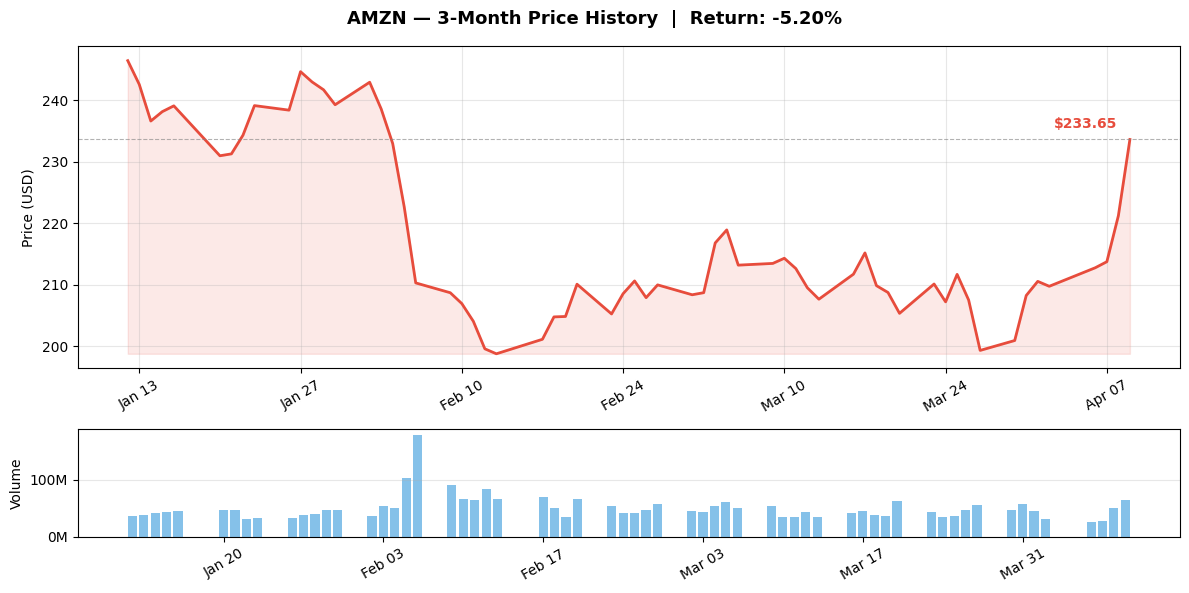

Period: 2026-01-12 to 2026-04-09  |  High: $248.94  |  Low: $196.0


In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

def plot_stock_history(symbol: str, period: str = "3mo"):
    hist = asyncio.run(call_tool("get_stock_history", {"symbol": symbol, "period": period}))
    dates  = [datetime.strptime(d["date"], "%Y-%m-%d") for d in hist["history"]]
    closes = [d["close"] for d in hist["history"]]
    vols   = [d["volume"] for d in hist["history"]]
    color  = "#2ecc71" if hist["period_return_pct"] >= 0 else "#e74c3c"

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                    gridspec_kw={"height_ratios": [3, 1]})
    fig.suptitle(
        symbol + f" — 3-Month Price History  |  Return: {hist['period_return_pct']:+.2f}%",
        fontsize=13, fontweight="bold"
    )
    ax1.plot(dates, closes, color=color, linewidth=2)
    ax1.fill_between(dates, closes, min(closes), alpha=0.12, color=color)
    ax1.axhline(closes[-1], color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax1.annotate(f"${closes[-1]:.2f}", xy=(dates[-1], closes[-1]),
                xytext=(-55, 8), textcoords="offset points",
                fontsize=10, color=color, fontweight="bold")
    ax1.set_ylabel("Price (USD)"); ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax1.tick_params(axis="x", rotation=30)
    ax2.bar(dates, vols, color="#3498db", alpha=0.6, width=0.8)
    ax2.set_ylabel("Volume")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax2.tick_params(axis="x", rotation=30); ax2.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
    print(f"Period: {hist['start_date']} to {hist['end_date']}  |  "
          f"High: ${hist['period_high']}  |  Low: ${hist['period_low']}")

plot_stock_history("AMZN")

## Part 7 — Build the Strands Agent

Wire the FastMCP HTTP server into a **Strands Agent** backed by AWS Bedrock.

Strands `MCPClient` uses `mcp.client.streamable_http.streamablehttp_client`
to connect to the running FastMCP HTTP server over the MCP protocol.
The agent discovers all `@mcp.tool` functions automatically.

<a href="https://ibb.co/b5Nzj91q"><img src="https://i.ibb.co/yFgWmj0G/Screenshot-2026-04-09-at-9-57-12-PM.png" alt="Screenshot-2026-04-09-at-9-57-12-PM" border="0"></a>

> **Requires AWS credentials.**

> In Google Colab: use the **Secrets** panel (key icon) to add
> `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, and `AWS_REGION`.

In [15]:
# Load from Colab Secrets
try:
    from google.colab import userdata
    os.environ["AWS_ACCESS_KEY_ID"]     = userdata.get("AWS_ACCESS_KEY_ID")
    os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
    os.environ["AWS_REGION"]            = userdata.get("AWS_REGION")
    print("Credentials loaded from Colab Secrets")
except Exception:
    print("Not in Colab — using environment credentials")

region = os.environ.get("AWS_REGION", "us-east-1")
print(f"AWS Region:      {region}")
print(f"Credentials set: {'Yes' if os.environ.get('AWS_ACCESS_KEY_ID') else 'No — set above'}")

Not in Colab — using environment credentials
AWS Region:      us-east-1
Credentials set: Yes


In [16]:
from strands import Agent
from strands.models.bedrock import BedrockModel
from strands.tools.mcp import MCPClient
from mcp.client.streamable_http import streamablehttp_client

SYSTEM_PROMPT = """
You are an expert Wall Street Stock Analyst specializing in data-driven insights.

Your goal is to provide institutional-grade financial analysis using the available Financial Datasets tools.

### OPERATIONAL GUIDELINES:
1. ALWAYS fetch real-time data using the tools before providing an opinion. Do not rely on your internal training data for stock prices or fundamentals.
2. STRUCTURE: Start with a "Bottom Line Up Front" (BLUF) summary, followed by Key Metrics, then a detailed analysis of Financial Statements (Income, Balance Sheet, Cash Flow) as requested.
3. CONTEXT: When analyzing a ticker, check for recent Insider Trades and Company News to identify potential catalysts or red flags.
4. DATA INTEGRITY: If a tool returns an error or missing data, state it clearly. Do not hallucinate numbers.
5. FORMATTING: Use tables for financial comparisons (e.g., Year-over-Year growth). Format currency in USD and use percentages for margins.

### ANALYSIS STEPS:
- For "Buy/Sell" queries: Analyze the P/E ratio relative to historical averages and check the most recent Cash Flow Statement for operational efficiency.
- For "Risk" queries: Prioritize the Balance Sheet (Debt-to-Equity) and recent Insider selling activity.
End every analysis with: 'This is for informational purposes only, not financial advice.'"""

# 1. AWS Bedrock model
model = BedrockModel(
    model_id="us.anthropic.claude-sonnet-4-20250514-v1:0",
    temperature=0.2,
    streaming=True,
    region_name=os.environ.get("AWS_REGION", "us-east-1"),
)

# 2. Strands MCPClient over HTTP
#    streamablehttp_client connects to the running FastMCP server.
#    Strands discovers all @mcp.tool functions automatically.
mcp_client = MCPClient(
    lambda: streamablehttp_client(MCP_URL)
)

# 3. Strands Agent
agent = Agent(
    model=model,
    tools=[mcp_client],
    system_prompt=SYSTEM_PROMPT,
)

print("Agent ready!")
print(f"MCP URL  : {MCP_URL}")

Agent ready!
MCP URL  : http://127.0.0.1:8765/mcp


## Part 8 — Run the Agent

Ask natural language questions. The agent calls the FastMCP HTTP server
to fetch data, then synthesizes a response using AWS Bedrock.

In [17]:
response = agent("Give me a brief analysis of Amazon (AMZN) stock.")

I'll provide you with a comprehensive analysis of Amazon (AMZN) stock. Let me gather the current data first.
Tool #1: get_stock_profile

Tool #2: get_stock_price

Tool #3: get_stock_financials

Tool #4: get_stock_news
## **BOTTOM LINE UP FRONT (BLUF)**
Amazon (AMZN) is currently trading at $233.65 with strong analyst support (Strong Buy rating, $281.27 target price). The stock shows solid fundamentals with improving profitability metrics and strong cash generation, though it trades at a premium valuation.

## **KEY METRICS**

| Metric | Value | Assessment |
|--------|--------|------------|
| **Current Price** | $233.65 (+5.60% today) | Strong daily performance |
| **Market Cap** | $2.51T | Mega-cap leader |
| **P/E Ratio** | 32.59x | Premium but reasonable for growth |
| **Revenue (TTM)** | $716.92B | Massive scale |
| **Profit Margin** | 10.83% | Healthy profitability |
| **ROE** | 22.29% | Excellent returns |
| **Free Cash Flow** | $23.79B | Strong cash generation |

## **FINANCIAL A

In [18]:
response = agent("Compare NVDA and AMZN — which looks more attractive right now?")

I'll compare NVIDIA (NVDA) and Amazon (AMZN) for you. Let me gather the current data for both stocks to provide a comprehensive side-by-side analysis.
Tool #5: compare_stocks

Tool #6: get_stock_price

Tool #7: get_stock_financials

Tool #8: get_stock_news
## **BOTTOM LINE UP FRONT (BLUF)**
**NVIDIA appears more attractive right now** despite higher valuation, driven by superior profitability metrics, explosive earnings growth potential, and dominant AI positioning. However, Amazon offers better diversification and more reasonable valuation for risk-averse investors.

## **HEAD-TO-HEAD COMPARISON**

| Metric | NVIDIA (NVDA) | Amazon (AMZN) | Winner |
|--------|---------------|---------------|---------|
| **Current Price** | $183.91 (+1.01%) | $233.65 (+5.60%) | AMZN (momentum) |
| **Market Cap** | $4.47T | $2.51T | NVDA (scale) |
| **P/E Ratio** | 37.53x | 32.59x | AMZN (value) |
| **YTD Return** | -2.6% | +3.2% | AMZN |
| **Target Upside** | 45.9% ($268.22) | 20.4% ($281.27) | **NVDA*

## Cleanup

Stop the background FastMCP HTTP server when done.

In [ ]:
server_proc.terminate()
server_proc.wait()
print(f"FastMCP HTTP server (PID {server_proc.pid}) stopped.")

FastMCP HTTP server (PID 7600) stopped.
